In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, hour, dayofweek
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, ClusteringEvaluator

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
spark = SparkSession.builder \
    .appName("BigQuery_to_PySpark_ML") \
    .getOrCreate()

26/09/26 01:56:03 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [5]:
PROJECT_ID = 'big-data-lunes-2026-1'
DATASET_ID = 'bank'
TABLE_ID = 'bank_transactions'
BUCKET_TEMP = 'big-data-lunes-20260223'

In [6]:
%%time
df_bank = spark.read.format("bigquery") \
    .option("table", f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}") \
    .load()

CPU times: user 4.16 ms, sys: 0 ns, total: 4.16 ms
Wall time: 6.01 s


In [7]:
df_bank.printSchema()

root
 |-- transaction_id: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- from_user_id: string (nullable = true)
 |-- from_name: string (nullable = true)
 |-- from_country: string (nullable = true)
 |-- from_bank: string (nullable = true)
 |-- from_location: string (nullable = true)
 |-- to_user_id: string (nullable = true)
 |-- to_name: string (nullable = true)
 |-- to_country: string (nullable = true)
 |-- to_bank: string (nullable = true)
 |-- to_location: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- currency: string (nullable = true)
 |-- transaction_type: string (nullable = true)
 |-- is_suspicious: boolean (nullable = true)
 |-- suspicious_pattern: string (nullable = true)



In [8]:
df_bank.count()

460311

In [9]:
df_base = df_bank.select(
    "amount", "from_country", "from_bank", "transaction_type", "timestamp", "is_suspicious"
).withColumn("hour", hour(col("timestamp"))) \
 .withColumn("day", dayofweek(col("timestamp"))) \
 .withColumn("label_real", col("is_suspicious").cast("double")) \
 .na.drop()

In [10]:
df_base.show()

+--------+------------+---------------+----------------+--------------------+-------------+----+---+----------+
|  amount|from_country|      from_bank|transaction_type|           timestamp|is_suspicious|hour|day|label_real|
+--------+------------+---------------+----------------+--------------------+-------------+----+---+----------+
| 8839.12|          AE|           HSBC|        transfer|2025-01-11 07:20:...|        false|   7|  7|       0.0|
| 92951.3|          AE|           HSBC|        transfer|2023-04-24 11:59:...|        false|  11|  2|       0.0|
| 62499.9|          AE|  Deutsche Bank|      withdrawal|2025-01-09 15:21:...|        false|  15|  5|       0.0|
| 77056.2|          AE|           HSBC|        transfer|2025-02-02 16:04:...|        false|  16|  1|       0.0|
|48297.98|          AE|           HSBC|        transfer|2024-12-30 06:57:...|        false|   6|  2|       0.0|
|93026.49|          AE|           HSBC|         deposit|2025-04-03 12:59:...|        false|  12|  5|    

In [14]:
cat_cols = ["from_country", "from_bank", "transaction_type"]

indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="skip") for c in cat_cols]

encoder = OneHotEncoder(inputCols=[c+"_idx" for c in cat_cols], outputCols=[c+"_vec" for c in cat_cols])

assembler = VectorAssembler(
    inputCols=["amount", "hour", "day"] + [c+"_vec" for c in cat_cols],
    outputCol="features_raw"
)

scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled")

In [15]:
%%time
prep_pipeline = Pipeline(stages=indexers + [encoder, assembler, scaler])
prep_model = prep_pipeline.fit(df_base)
df_final = prep_model.transform(df_base)

CPU times: user 98.4 ms, sys: 8.54 ms, total: 107 ms
Wall time: 25.8 s


In [16]:
df_final.show()

+--------+------------+---------------+----------------+--------------------+-------------+----+---+----------+----------------+-------------+--------------------+----------------+-------------+--------------------+--------------------+--------------------+
|  amount|from_country|      from_bank|transaction_type|           timestamp|is_suspicious|hour|day|label_real|from_country_idx|from_bank_idx|transaction_type_idx|from_country_vec|from_bank_vec|transaction_type_vec|        features_raw|     features_scaled|
+--------+------------+---------------+----------------+--------------------+-------------+----+---+----------+----------------+-------------+--------------------+----------------+-------------+--------------------+--------------------+--------------------+
| 8839.12|          AE|           HSBC|        transfer|2025-01-11 07:20:...|        false|   7|  7|       0.0|            13.0|          1.0|                 0.0| (14,[13],[1.0])|(9,[1],[1.0])|       (4,[0],[1.0])|(30,[0,1,2,

In [17]:
%%time
kmeans_test = KMeans(featuresCol="features_scaled", k=3, seed=42)
model_test = kmeans_test.fit(df_final)

CPU times: user 18.3 ms, sys: 11.9 ms, total: 30.2 ms
Wall time: 26 s


In [19]:
model_test.summary

In [23]:
model_test.summary.trainingCost

12821532.430806058

In [24]:
%%time
print("Calculando el método del codo para K de 2 a 15...")
cost = []
n = 6
for k in range(2, n):
    kmeans_test = KMeans(featuresCol="features_scaled", k=k, seed=42)
    model_test = kmeans_test.fit(df_final)
    # En versiones recientes de Spark usamos getSummary().trainingCost
    cost.append(model_test.summary.trainingCost)

Calculando el método del codo para K de 2 a 15...


CPU times: user 66.2 ms, sys: 23.9 ms, total: 90.2 ms
Wall time: 1min 7s


In [27]:
!pip install plotly

ERROR: Could not find a version that satisfies the requirement plotly (from versions: none)
ERROR: No matching distribution found for plotly


In [31]:
!gsutil cp gs://big-data-lunes-20260223/plotly-7.1.0-py3-none-any.whl .
!pip install plotly-7.1.0-py3-none-any.whl

Copying gs://big-data-lunes-20260223/plotly-7.1.0-py3-none-any.whl...
/ [1 files][  9.2 MiB/  9.2 MiB]                                                
Operation completed over 1 objects/9.2 MiB.                                      
Processing /plotly-7.1.0-py3-none-any.whl
^C


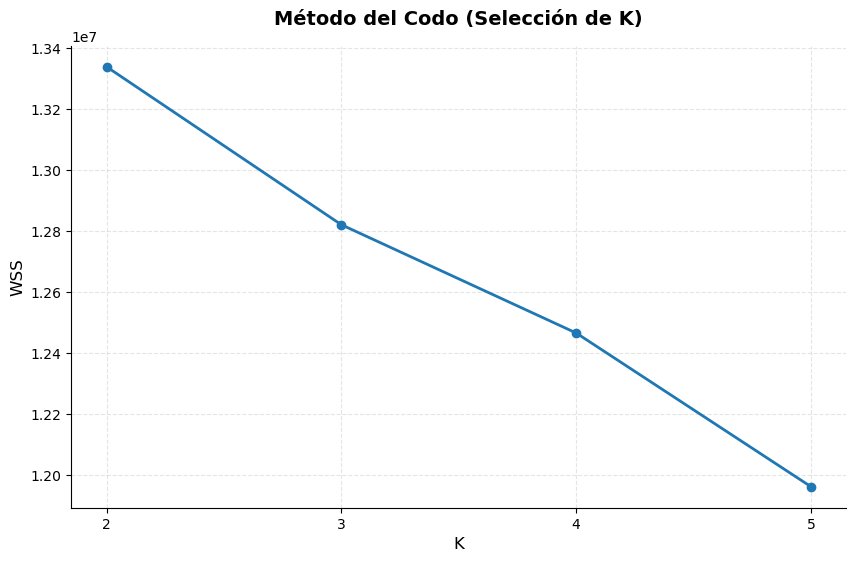

In [38]:
import matplotlib

# Forzar a que el objeto RcParams redirija '_get' al método estándar 'get'
RcParamsClass = type(matplotlib.rcParams)
if not hasattr(RcParamsClass, '_get'):
    RcParamsClass._get = RcParamsClass.get
# ----------------------------------------------------

# Ahora ya puedes importar pyplot de forma segura sin que explote
import matplotlib.pyplot as plt
import pandas as pd

# Crear DataFrame para el codo
df_elbow = pd.DataFrame({
    'K': list(range(2, n)),
    'WSS': cost
})

# Inicializar la gráfica (limpia, sin estilos externos)
fig, ax = plt.subplots(figsize=(10, 6))

# Graficar la línea y los puntos
ax.plot(
    df_elbow['K'], 
    df_elbow['WSS'], 
    marker='o',          # Puntos en los nodos
    linestyle='-',       # Línea continua
    color='#1f77b4',     # Azul estándar
    linewidth=2,         # Grosor de la línea
    markersize=6         # Tamaño del punto
)

# Títulos y etiquetas de los ejes
ax.set_title('Método del Codo (Selección de K)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('K', fontsize=12)
ax.set_ylabel('WSS', fontsize=12)

# Añadir cuadrícula manualmente para emular el estilo limpio
ax.grid(True, linestyle='--', alpha=0.5, color='#ccc')

# Forzar a que el eje X muestre números enteros (ideal para K)
ax.set_xticks(df_elbow['K'])

# Quitar los bordes superior y derecho para un diseño más moderno/limpio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar la gráfica en el notebook de Apache Spark
plt.show()

In [39]:

# 4. ENTRENAMIENTO DEL MODELO K-MEANS FINAL Y PCA
print("\nEntrenando modelo K-Means final y aplicando PCA...")
k_optimo = 4 # Asume este K basado en el gráfico del codo anterior
kmeans_final = KMeans(featuresCol="features_scaled", k=k_optimo, predictionCol="cluster", seed=42)
model_final = kmeans_final.fit(df_final)
df_res = model_final.transform(df_final)




Entrenando modelo K-Means final y aplicando PCA...


In [40]:
# Reducción de dimensionalidad con PCA para visualización 2D
pca = PCA(k=2, inputCol="features_scaled", outputCol="pca_features")
pca_model = pca.fit(df_res)
df_vis = pca_model.transform(df_res)

In [47]:
pca_model.explainedVariance

DenseVector([0.0417, 0.0417])

In [45]:
df_vis.select(col("pca_features")).show(truncate = False)

+--------------------------------------------+
|pca_features                                |
+--------------------------------------------+
|[-2.231055042046779,-0.34553325740733926]   |
|[-2.246046385978417,-0.34076630558808657]   |
|[1.1688649498094414,-1.6534107239683555]    |
|[-2.241919972265386,-0.35723727181173304]   |
|[-2.250938841338427,-0.34478504791793907]   |
|[0.10313547613018986,0.040090569561135964]  |
|[0.2119571896410583,0.05017514351058955]    |
|[-0.1444805871887292,-0.037610457135970866] |
|[0.6765604818392166,1.8613646029931135]     |
|[1.1592477874228957,-1.7393179355844561]    |
|[-2.0729236679594907,-0.2906220649078105]   |
|[-0.05137221257118081,-0.012056541936872799]|
|[-2.204015122726299,-0.3225277734593512]    |
|[0.02400273064924692,-0.028892173137039158] |
|[0.2587273473893451,-0.03850253208285881]   |
|[1.091135675649553,-1.6247752296162787]     |
|[0.16122327200555292,0.035096200807936226]  |
|[1.033759028713538,-1.559392584252631]      |
|[-2.23555324

Iniciando proceso de visualización segura...


Total de registros en df_vis: 460311
El dataset es grande. Muestreando al 3.26% para seguridad.


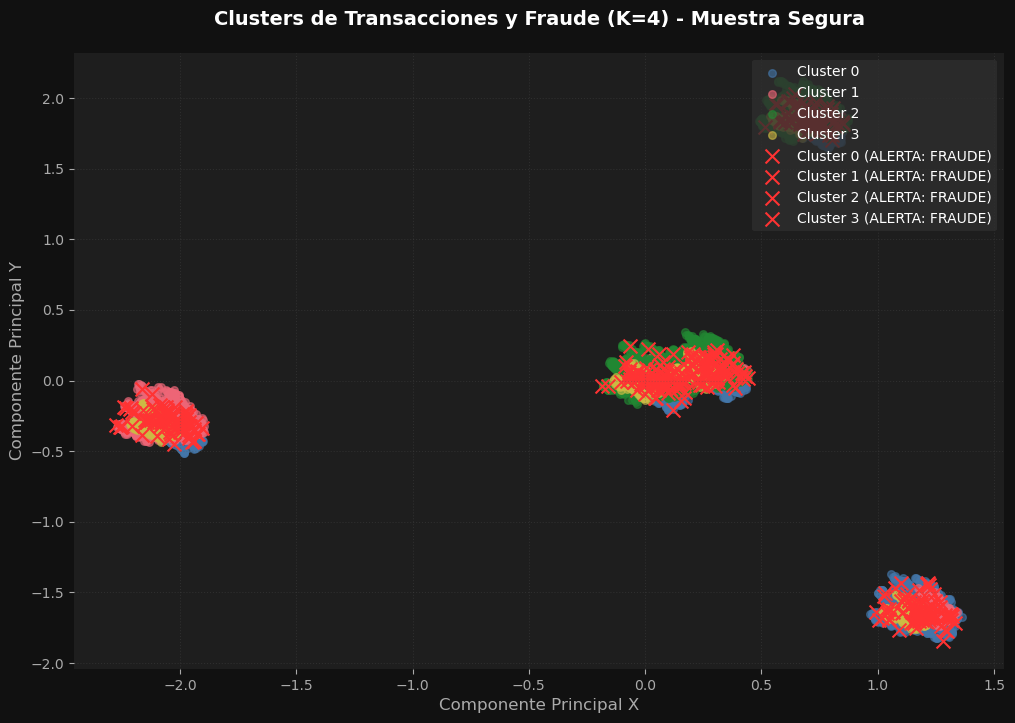

In [49]:
# --- PARCHE DE COMPATIBILIDAD PARA GCP JUPYTERLAB ---
import matplotlib
RcParamsClass = type(matplotlib.rcParams)
if not hasattr(RcParamsClass, '_get'):
    RcParamsClass._get = RcParamsClass.get
# ----------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd

# --- CONFIGURACIÓN DE SEGURIDAD ---
MAX_RECORDS_DRIVER = 15000  # Límite seguro para no saturar la RAM del Driver
print("Iniciando proceso de visualización segura...")

# 1. Calcular el conteo total de registros disponibles tras PCA
total_count = df_vis.count()
print(f"Total de registros en df_vis: {total_count}")

# 2. Determinar la fracción de muestreo óptima
sampling_fraction = min(1.0, MAX_RECORDS_DRIVER / total_count)

if sampling_fraction < 1.0:
    print(f"El dataset es grande. Muestreando al {sampling_fraction*100:.2f}% para seguridad.")
else:
    print("Dataset manejable. Procediendo con todos los datos seleccionados.")

# 3. Ejecutar el SELECT y el muestreo antes de toPandas()
df_to_convert = df_vis.select(
    "pca_features", "cluster", "label_real", "amount", "from_bank"
).sample(withReplacement=False, fraction=sampling_fraction, seed=42)

# Ahora es seguro convertir
sample_pd = df_to_convert.toPandas()

# 4. PROCESAMIENTO EN PANDAS
coords = pd.DataFrame(
    sample_pd['pca_features'].apply(lambda x: x.toArray()).tolist(), 
    columns=['x', 'y']
)
sample_pd = pd.concat([sample_pd, coords], axis=1)

# Crear etiqueta legible para el gráfico
sample_pd['Tipo'] = sample_pd['label_real'].apply(lambda x: 'ALERTA: FRAUDE' if x == 1.0 else 'Normal')

# 5. GRÁFICO SCATTER (Matplotlib con paleta "Safe" equivalente)
# Forzamos un fondo oscuro similar a 'plotly_dark' de forma manual y robusta
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#111111')
ax.set_facecolor('#1e1e1e')

# Paleta de colores cualitativa segura (equivalente a px.colors.qualitative.Safe)
colores_safe = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']
clusters_unicos = sorted(sample_pd['cluster'].unique())
color_map = {c: colores_safe[i % len(colores_safe)] for i, c in enumerate(clusters_unicos)}

# Mapeo de marcadores según el 'Tipo' (Círculo para Normal, 'X' grande para Fraude)
marcadores_map = {'Normal': {'marker': 'o', 'alpha': 0.6, 'size': 30},
                  'ALERTA: FRAUDE': {'marker': 'x', 'alpha': 1.0, 'size': 100}}

# Graficar iterando por tipo y cluster para generar la leyenda correctamente
for tipo, config in marcadores_map.items():
    df_tipo = sample_pd[sample_pd['Tipo'] == tipo]
    
    for cluster in clusters_unicos:
        df_sub = df_tipo[df_tipo['cluster'] == cluster]
        
        if not df_sub.empty:
            # Si es fraude, fijamos un color llamativo (ej. Rojo) o seguimos el mapa de clusters
            color_punto = '#FF3333' if tipo == 'ALERTA: FRAUDE' else color_map[cluster]
            
            ax.scatter(
                df_sub['x'], df_sub['y'],
                c=color_punto,
                marker=config['marker'],
                s=config['size'],
                alpha=config['alpha'],
                label=f"Cluster {cluster} ({tipo})" if tipo == 'ALERTA: FRAUDE' else f"Cluster {cluster}"
            )

# Título y etiquetas con estilos claros sobre fondo oscuro
ax.set_title(f"Clusters de Transacciones y Fraude (K={k_optimo}) - Muestra Segura", 
             color='white', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Componente Principal X', color='#aaaaaa', fontsize=12)
ax.set_ylabel('Componente Principal Y', color='#aaaaaa', fontsize=12)

# Configurar cuadrícula sutil y ejes
ax.grid(True, linestyle=':', alpha=0.3, color='#555555')
ax.tick_params(colors='#aaaaaa', labelsize=10)

# Remover los bordes de la gráfica para un look moderno
for spine in ax.spines.values():
    spine.set_visible(False)

# Construir la leyenda de forma limpia evitando duplicados gigantes
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), 
          facecolor='#2e2e2e', edgecolor='none', labelcolor='white', loc='upper right')

# Desplegar en el Notebook de Apache Spark sin requerir internet
plt.show()

In [50]:
%%time 

df_fixed = df_bank.withColumn("label", col("is_suspicious").cast("double")) \
                  .withColumn("is_suspicious_num", col("is_suspicious").cast("double")) \
                  .na.drop(subset=["amount", "is_suspicious"])

idx_bank = StringIndexer(inputCol="from_bank", outputCol="bank_idx", handleInvalid="skip")
idx_type = StringIndexer(inputCol="transaction_type", outputCol="type_idx", handleInvalid="skip")

# Etapa 2: Encoder (Números -> Vectores Binarios)
ohe = OneHotEncoder(
    inputCols=["bank_idx", "type_idx"], 
    outputCols=["bank_vec", "type_vec"]
)

# Etapa 3: Ensamblar (Monto + Vectores OHE)
ass_c = VectorAssembler(
    inputCols=["amount", "bank_vec", "type_vec"], 
    outputCol="features_c"
)

# Etapa 4: Algoritmo
rf = RandomForestClassifier(labelCol="label", featuresCol="features_c", numTrees=50)

# Pipeline de Clasificación
pipe_rf = Pipeline(stages=[idx_bank, idx_type, ohe, ass_c, rf])

# Entrenamiento y Evaluación
train, test = df_fixed.randomSplit([0.8, 0.2], seed=42)
model_rf = pipe_rf.fit(train)
preds = model_rf.transform(test)

evaluator = BinaryClassificationEvaluator(labelCol="label")
auc = evaluator.evaluate(preds)
print(f"\n>>> AUC Final con OHE: {auc:.4f} <<<")


>>> AUC Final con OHE: 0.5000 <<<
CPU times: user 110 ms, sys: 53.9 ms, total: 164 ms
Wall time: 1min 6s


In [52]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.functions import vector_to_array
import sys

In [53]:
# 1. DEFINICIÓN DEL AUTOENCODER (MLP como aproximador)
# Capas: [Entrada, 8 (Bottleneck), 4, 2 (Salida Binaria)]
input_dim = len(df_final.select("features_scaled").first()[0])
layers = [input_dim, 8, 4, 2]

In [54]:
autoencoder = MultilayerPerceptronClassifier(
    layers=layers, seed=42, featuresCol="features_scaled", labelCol="label_real"
)

In [55]:
model_ae = autoencoder.fit(df_final)
df_predictions = model_ae.transform(df_final)

# Calculamos el Score de Anomalía (1 - probabilidad de ser 'Normal')
df_predictions = df_predictions.withColumn("p_array", vector_to_array("probability")) \
                               .withColumn("anomaly_score", 1 - col("p_array")[0])

In [56]:
df_predictions.show()

+--------+------------+---------------+----------------+--------------------+-------------+----+---+----------+----------------+-------------+--------------------+----------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+--------------------+--------------------+
|  amount|from_country|      from_bank|transaction_type|           timestamp|is_suspicious|hour|day|label_real|from_country_idx|from_bank_idx|transaction_type_idx|from_country_vec|from_bank_vec|transaction_type_vec|        features_raw|     features_scaled|       rawPrediction|         probability|prediction|             p_array|       anomaly_score|
+--------+------------+---------------+----------------+--------------------+-------------+----+---+----------+----------------+-------------+--------------------+----------------+-------------+--------------------+--------------------+--------------------+--------------------+----------------

In [60]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc

# Parche obligatorio para evitar errores de renderizado en GCP JupyterLab
RcParamsClass = type(matplotlib.rcParams)
if not hasattr(RcParamsClass, '_get'):
    RcParamsClass._get = RcParamsClass.get

MAX_ROWS = 10000
total_rows = df_predictions.count()
print(f"Filas totales en el DataFrame: {total_rows}")

if total_rows > MAX_ROWS:
    print(f"¡Peligro! El dataset es demasiado grande ({total_rows} filas).")
    print(f"Tomando una muestra aleatoria para proteger la memoria del Driver...")
    fraction = MAX_ROWS / total_rows
    df_to_plot = df_predictions.sample(withReplacement=False, fraction=fraction, seed=42)
else:
    print("El dataset es de tamaño seguro. Procediendo sin muestreo.")
    df_to_plot = df_predictions

# Conversión segura a Pandas local
sample_pd = df_to_plot.toPandas()

Filas totales en el DataFrame: 460311
¡Peligro! El dataset es demasiado grande (460311 filas).
Tomando una muestra aleatoria para proteger la memoria del Driver...


In [62]:
type(sample_pd)

pandas.core.frame.DataFrame

/tmp/ipykernel_16592/2600429736.py:17: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax1.scatter(


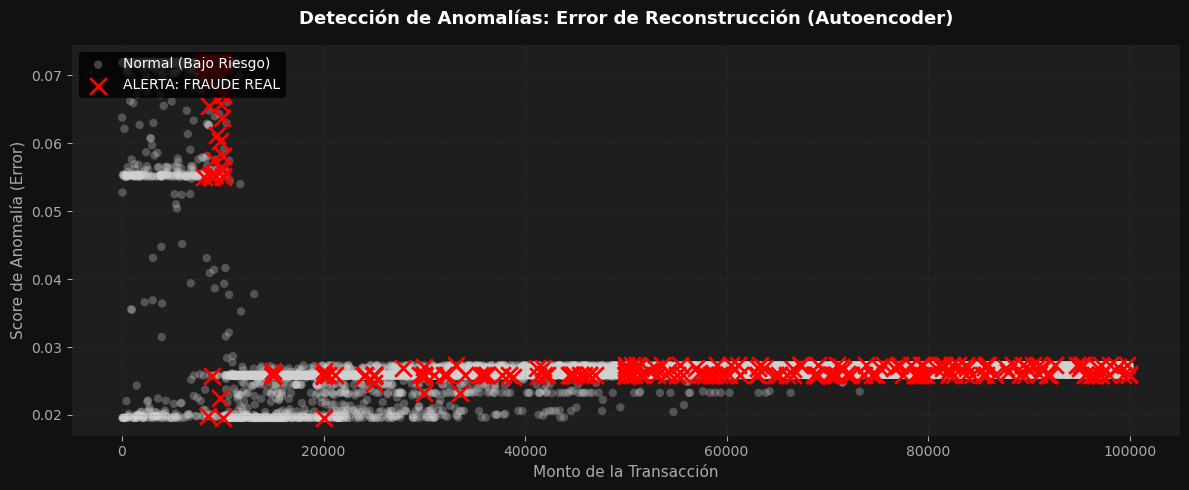

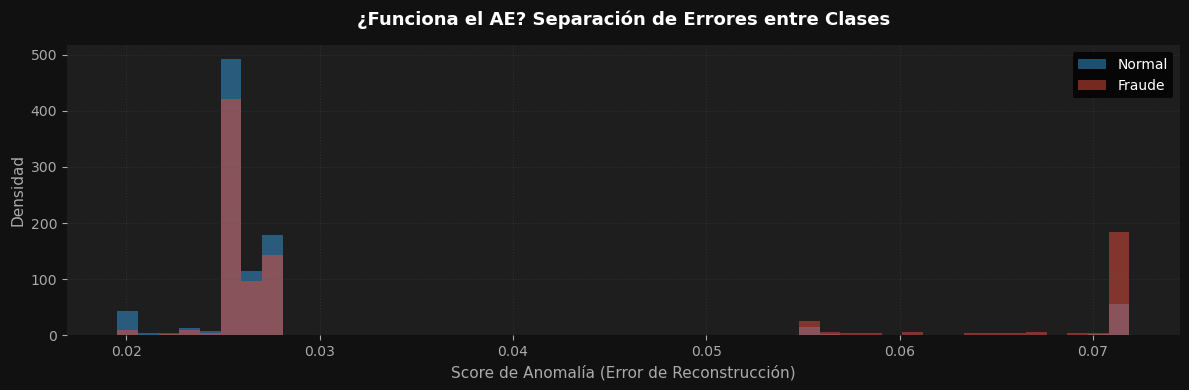


Umbral definido (Percentil 95 de normales): 0.0719

--- Matriz de Confusión Estructurada ---
Predicción AE     0    1
Realidad                
0.0            9320  491
1.0             256   44


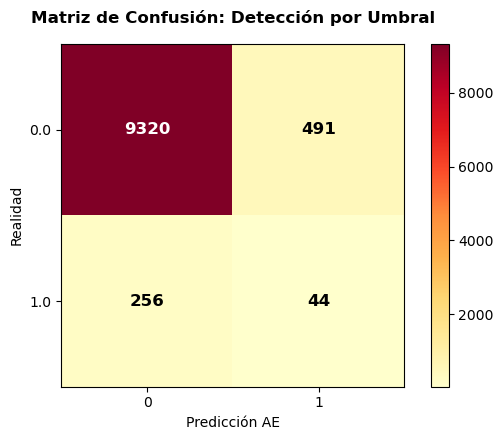

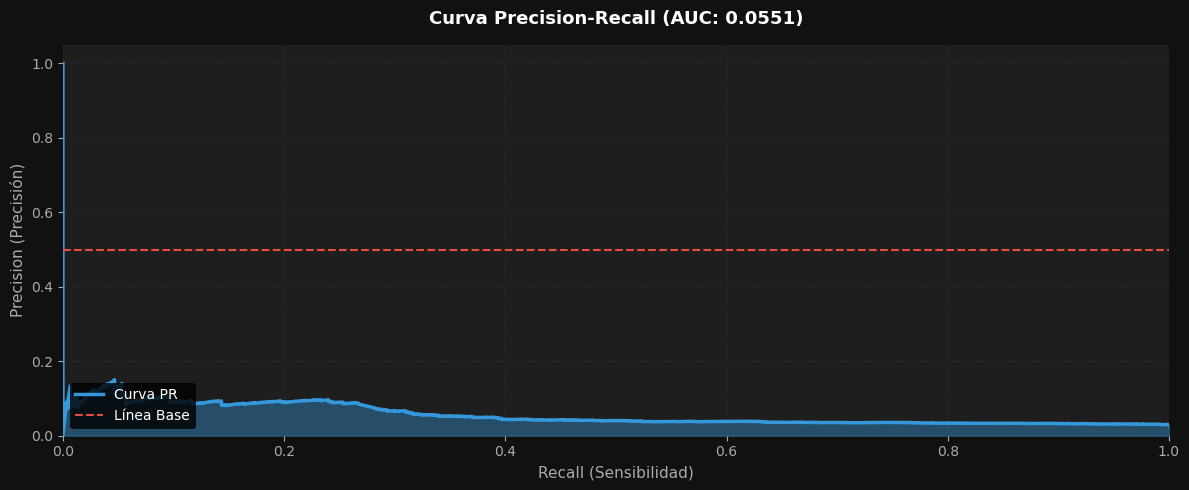

In [63]:

# Separación de las clases en Pandas para los gráficos
normales = sample_pd[sample_pd['label_real'] == 0]
fraudulentos = sample_pd[sample_pd['label_real'] == 1]

# =====================================================================
# 2. GRÁFICO 1: DETECCIÓN DE ANOMALÍAS (SCATTER AUTOENCODER)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(12, 5), facecolor='#111111')
ax1.set_facecolor('#1e1e1e')

# Capa 1: Normales
ax1.scatter(
    normales['amount'], normales['anomaly_score'],
    color='lightgrey', s=36, alpha=0.3, edgecolors='none', label='Normal (Bajo Riesgo)'
)
# Capa 2: Fraudulentos
ax1.scatter(
    fraudulentos['amount'], fraudulentos['anomaly_score'],
    color='red', s=144, alpha=1.0, marker='x', linewidths=2, edgecolors='darkred', label='ALERTA: FRAUDE REAL'
)

ax1.set_title("Detección de Anomalías: Error de Reconstrucción (Autoencoder)", color='white', fontsize=13, pad=15, fontweight='bold')
ax1.set_xlabel("Monto de la Transacción", color='#aaaaaa', fontsize=11)
ax1.set_ylabel("Score de Anomalía (Error)", color='#aaaaaa', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.3, color='#555555')
ax1.tick_params(colors='#aaaaaa')
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.legend(loc="upper left", facecolor=(0,0,0,0.5), edgecolor='none', labelcolor='white')
plt.tight_layout()
plt.show()

# =====================================================================
# 3. GRÁFICO 2: DENSIDAD (DISTPLOT EQUIVALENTE)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(12, 4), facecolor='#111111')
ax2.set_facecolor('#1e1e1e')

# Histogramas normados para emular la densidad de distribución de Plotly
bins = np.linspace(sample_pd['anomaly_score'].min(), sample_pd['anomaly_score'].max(), 50)
ax2.hist(normales['anomaly_score'], bins=bins, density=True, alpha=0.5, color='#3498db', label='Normal')
ax2.hist(fraudulentos['anomaly_score'], bins=bins, density=True, alpha=0.5, color='#e74c3c', label='Fraude')

ax2.set_title("¿Funciona el AE? Separación de Errores entre Clases", color='white', fontsize=13, pad=15, fontweight='bold')
ax2.set_xlabel("Score de Anomalía (Error de Reconstrucción)", color='#aaaaaa', fontsize=11)
ax2.set_ylabel("Densidad", color='#aaaaaa', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.3, color='#555555')
ax2.tick_params(colors='#aaaaaa')
for spine in ax2.spines.values(): spine.set_visible(False)
ax2.legend(loc="upper right", facecolor=(0,0,0,0.5), edgecolor='none', labelcolor='white')
plt.tight_layout()
plt.show()

# =====================================================================
# 4. MATRIZ DE CONFUSIÓN Y GRÁFICO 3 (HEATMAP)
# =====================================================================
threshold = normales['anomaly_score'].quantile(0.95)
print(f"\nUmbral definido (Percentil 95 de normales): {threshold:.4f}")

sample_pd['prediccion_anomalia'] = (sample_pd['anomaly_score'] > threshold).astype(int)

# Crear matriz cruzada
matriz = pd.crosstab(
    sample_pd['label_real'], 
    sample_pd['prediccion_anomalia'], 
    rownames=['Realidad'], 
    colnames=['Predicción AE']
)
print("\n--- Matriz de Confusión Estructurada ---")
print(matriz)

# Mapa de calor de la Matriz
fig3, ax3 = plt.subplots(figsize=(6, 4.5))
cax = ax3.imshow(matriz.values, cmap='YlOrRd', interpolation='nearest')
fig3.colorbar(cax)

ax3.set_title("Matriz de Confusión: Detección por Umbral", fontsize=12, pad=15, fontweight='bold')
ax3.set_xticks(np.arange(len(matriz.columns)))
ax3.set_yticks(np.arange(len(matriz.index)))
ax3.set_xticklabels(matriz.columns)
ax3.set_yticklabels(matriz.index)
ax3.set_xlabel('Predicción AE', fontsize=10)
ax3.set_ylabel('Realidad', fontsize=10)

# Escribir los números dentro de los cuadrantes
for i in range(len(matriz.index)):
    for j in range(len(matriz.columns)):
        ax3.text(j, i, str(matriz.iloc[i, j]), ha='center', va='center', 
                 color='black' if matriz.iloc[i, j] < (matriz.values.max()/2) else 'white',
                 fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. GRÁFICO 4: CURVA PRECISION-RECALL (ÁREA EQUIVALENTE)
# =====================================================================
precision, recall, _ = precision_recall_curve(sample_pd['label_real'], sample_pd['anomaly_score'])
area_bajo_curva = auc(recall, precision)

fig4, ax4 = plt.subplots(figsize=(12, 5), facecolor='#111111')
ax4.set_facecolor('#1e1e1e')

# Rellenar el área bajo la curva (emula px.area)
ax4.fill_between(recall, precision, color='#3498db', alpha=0.4)
ax4.plot(recall, precision, color='#3498db', linewidth=2.5, label='Curva PR')

# Línea base aleatoria (dash) equivalente al layout original de Plotly
ax4.axhline(y=0.5, color='#e74c3c', linestyle='--', linewidth=1.5, label='Línea Base')

ax4.set_title(f"Curva Precision-Recall (AUC: {area_bajo_curva:.4f})", color='white', fontsize=13, pad=15, fontweight='bold')
ax4.set_xlabel("Recall (Sensibilidad)", color='#aaaaaa', fontsize=11)
ax4.set_ylabel("Precision (Precisión)", color='#aaaaaa', fontsize=11)
ax4.grid(True, linestyle=':', alpha=0.3, color='#555555')
ax4.tick_params(colors='#aaaaaa')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
for spine in ax4.spines.values(): spine.set_visible(False)
ax4.legend(loc="lower left", facecolor=(0,0,0,0.5), edgecolor='none', labelcolor='white')

plt.tight_layout()
plt.show()